# FarmTech Solutions – Previsão de Rendimento de Safra (Fase 5)

**Contexto:** Este projeto foi desenvolvido para a FarmTech Solutions, em uma fazenda de médio porte (cerca de 200 hectares) que produz diversas culturas. O objetivo é analisar dados de condições de solo e temperatura em relação ao tipo de cultura e **prever o rendimento da safra**, além de explorar **tendências de produtividade** por meio de técnicas de aprendizado não supervisionado (clusterização).

**Dataset:** `crop_yield.csv` – variáveis de precipitação, umidade, temperatura e rendimento por cultura.

In [36]:
# Importações necessárias para EDA, clustering e modelagem
import pandas as pd       # manipulação de dados em tabelas
import numpy as np        # operações numéricas
import matplotlib.pyplot as plt  # gráficos
import seaborn as sns     # visualizações estatísticas
from pathlib import Path  # caminhos de arquivo multiplataforma

# Pré-processamento e modelagem (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')  # suprime avisos para saída mais limpa
sns.set_style('whitegrid')
%matplotlib inline  

In [7]:
# Carrega o dataset (caminho relativo: funciona em notebooks/ ou na raiz do repo)
data_path = Path('..') / 'data' / 'crop_yield.csv'
if not data_path.exists():
    data_path = Path('data') / 'crop_yield.csv'
df = pd.read_csv(data_path)  # lê CSV para DataFrame
df.head(10)  # exibe as 10 primeiras linhas

,Cultura,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
0,Soja,2.5,12.3,68,24.5,3.2
1,Milho,1.8,10.5,62,26.0,4.1
2,Trigo,3.2,14.1,72,20.0,2.8
3,Soja,2.0,11.8,65,25.0,3.5
4,Milho,2.8,13.0,70,23.5,3.9
5,Trigo,2.1,12.0,64,21.0,3.0
6,Soja,3.5,15.0,75,22.0,2.9
7,Milho,1.5,9.8,58,27.0,4.3
8,Trigo,2.9,13.5,71,19.5,2.7
9,Soja,2.2,12.5,66,24.0,3.4


## 1. Análise Exploratória (EDA)

A seguir, analisamos a estrutura dos dados, estatísticas descritivas e possíveis problemas (valores nulos, tipos, distribuições).

In [8]:
# Dimensões e tipos das colunas
print('Dimensões:', df.shape)  # (linhas, colunas)
print('\nTipos e não-nulos:')
df.info()  # tipos de dados e contagem de não-nulos
print('\nValores nulos por coluna:')
print(df.isnull().sum())  # verifica dados faltantes

Dimensões: (30, 6)

Tipos e não-nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Cultura                               30 non-null     object 
 1   Precipitação (mm dia 1)               30 non-null     float64
 2   Umidade específica a 2 metros (g/kg)  30 non-null     float64
 3   Umidade relativa a 2 metros (%)       30 non-null     int64  
 4   Temperatura a 2 metros (ºC)           30 non-null     float64
 5   Rendimento                            30 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.5+ KB

Valores nulos por coluna:
Cultura                                 0
Precipitação (mm dia 1)                 0
Umidade específica a 2 metros (g/kg)    0
Umidade relativa a 2 metros (%)         0
Temperatura a 2 metros (ºC)             0
Rendimento              

In [9]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Precipitação (mm dia 1),Umidade específica a 2 metros (g/kg),Umidade relativa a 2 metros (%),Temperatura a 2 metros (ºC),Rendimento
count,30.00000,30.000000,30.000000,30.000000,30.000000
mean,2.52000,12.473333,66.666667,23.183333,3.413333
std,0.51622,1.398258,4.844715,2.506830,0.531578
min,1.50000,9.800000,58.000000,19.000000,2.600000
25%,2.12500,11.275000,63.000000,21.000000,2.925000
50%,2.55000,12.500000,66.500000,23.250000,3.400000
75%,2.90000,13.500000,70.750000,25.000000,3.875000
max,3.50000,15.000000,75.000000,27.500000,4.400000


In [11]:
# Contagem por cultura
print('Contagem por Cultura:')
print(df['Cultura'].value_counts())

Contagem por Cultura:
Cultura
Soja     10
Milho    10
Trigo    10
Name: count, dtype: int64


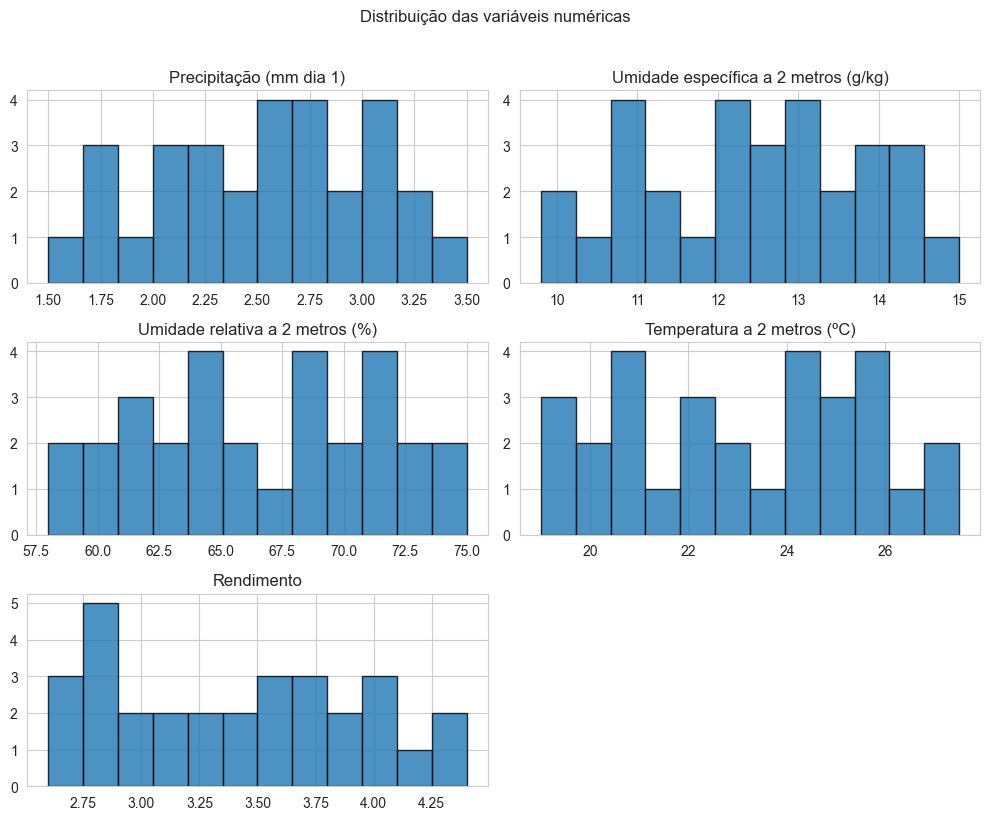

In [12]:
# Distribuições das variáveis numéricas (histogramas)
num_cols = [c for c in df.columns if df[c].dtype in ['float64', 'int64']]
df[num_cols].hist(bins=12, figsize=(10, 8), edgecolor='black', alpha=0.8)
plt.suptitle('Distribuição das variáveis numéricas', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

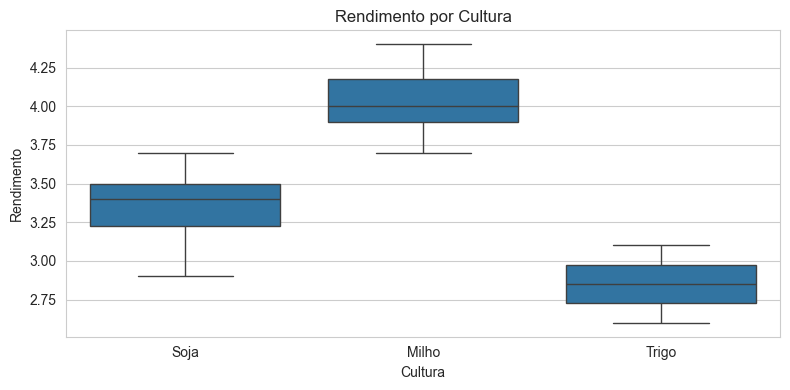

In [13]:
# Boxplots: Rendimento por Cultura
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Cultura', y='Rendimento')
plt.title('Rendimento por Cultura')
plt.tight_layout()
plt.show()

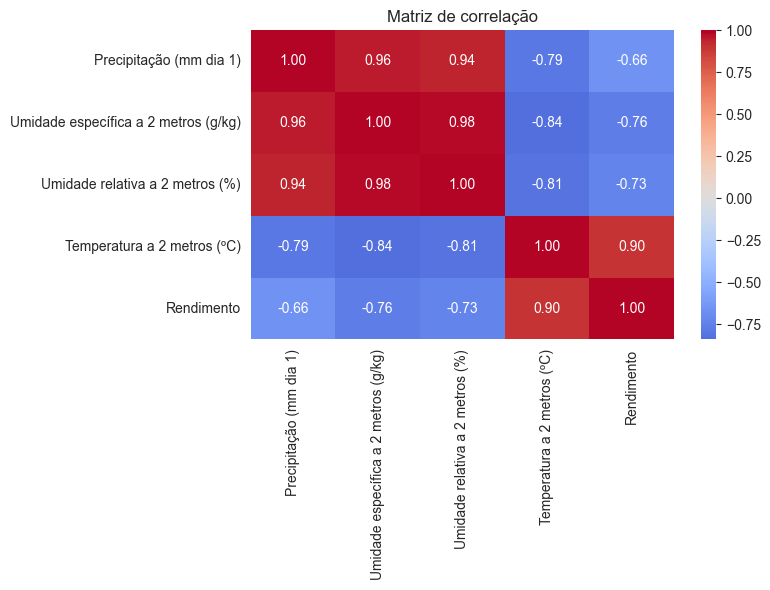

In [14]:
# Correlação entre variáveis numéricas (heatmap)
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()

**Conclusões da EDA:** Com base nas estatísticas e gráficos, avaliamos a qualidade dos dados (completude, tipos), a relação das variáveis com o rendimento e possíveis outliers ou valores atípicos que serão melhor explorados na clusterização.

## 2. Clusterização (tendências de produtividade e outliers)

Utilizamos técnicas de aprendizado não supervisionado para identificar grupos de produtividade e cenários discrepantes (outliers).

In [20]:
# Preparação para clustering: apenas variáveis numéricas + Cultura codificada
df_clust = df.copy()
le = LabelEncoder()
df_clust['Cultura_enc'] = le.fit_transform(df_clust['Cultura'].astype(str))  # categorias -> números
features_clust = [c for c in df_clust.columns if c != 'Cultura' and c != 'Rendimento']
X_clust = df_clust[features_clust]
scaler_clust = StandardScaler()  # normalização (média 0, desvio 1)
X_clust_scaled = scaler_clust.fit_transform(X_clust)

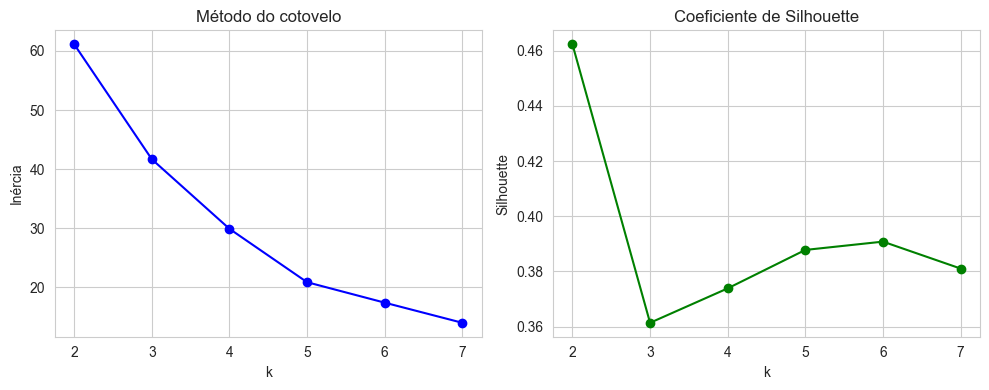

In [21]:
# Método do cotovelo e silhouette para escolher k (K-Means)
inertias = []
silhouettes = []
from sklearn.metrics import silhouette_score
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('k')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do cotovelo')
ax2.plot(K_range, silhouettes, 'go-')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette')
ax2.set_title('Coeficiente de Silhouette')
plt.tight_layout()
plt.show()

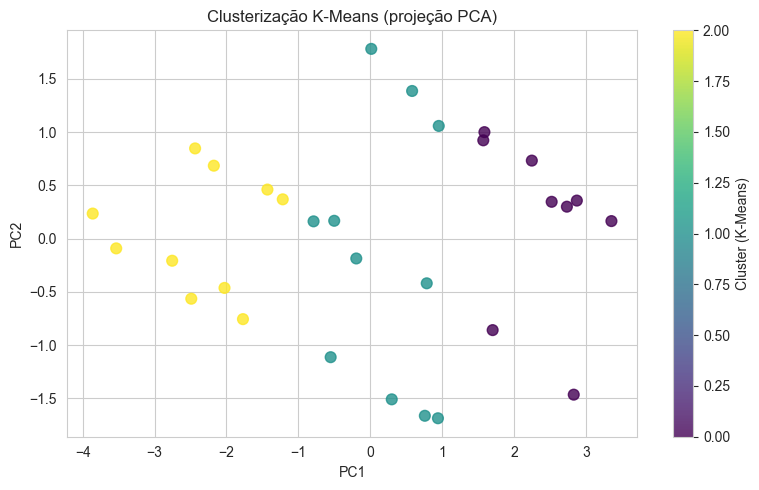

In [22]:
# K-Means com k escolhido (ex.: 3) e visualização em 2D via PCA
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clust['cluster_kmeans'] = kmeans.fit_predict(X_clust_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)
df_clust['PC1'] = X_pca[:, 0]
df_clust['PC2'] = X_pca[:, 1]

plt.figure(figsize=(8, 5))
scatter = plt.scatter(df_clust['PC1'], df_clust['PC2'], c=df_clust['cluster_kmeans'], cmap='viridis', s=60, alpha=0.8)
plt.colorbar(scatter, label='Cluster (K-Means)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusterização K-Means (projeção PCA)')
plt.tight_layout()
plt.show()

In [23]:
# Tendência de produtividade por cluster (média de Rendimento)
print('Rendimento médio por cluster (K-Means):')
print(df_clust.groupby('cluster_kmeans')['Rendimento'].agg(['mean', 'count']))

Rendimento médio por cluster (K-Means):
                    mean  count
cluster_kmeans                 
0               2.822222      9
1               3.427273     11
2               3.930000     10


In [24]:
# DBSCAN para detecção de outliers (cluster -1 = ruído)
db = DBSCAN(eps=1.2, min_samples=3)
df_clust['cluster_dbscan'] = db.fit_predict(X_clust_scaled)
n_noise = (df_clust['cluster_dbscan'] == -1).sum()
print(f'Registros classificados como outliers (ruído) pelo DBSCAN: {n_noise}')
print('Contagem por cluster DBSCAN:')
print(df_clust['cluster_dbscan'].value_counts().sort_index())

Registros classificados como outliers (ruído) pelo DBSCAN: 1
Contagem por cluster DBSCAN:
cluster_dbscan
-1     1
 0     9
 1     6
 2    10
 3     4
Name: count, dtype: int64


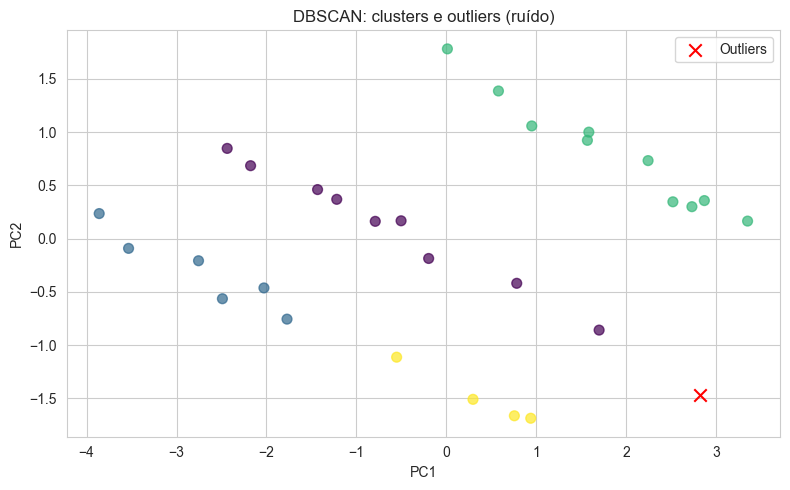

In [25]:
# Visualização: PCA colorido por cluster DBSCAN (outliers em destaque)
plt.figure(figsize=(8, 5))
mask_out = df_clust['cluster_dbscan'] == -1
plt.scatter(df_clust.loc[~mask_out, 'PC1'], df_clust.loc[~mask_out, 'PC2'], c=df_clust.loc[~mask_out, 'cluster_dbscan'], cmap='viridis', s=50, alpha=0.7)
plt.scatter(df_clust.loc[mask_out, 'PC1'], df_clust.loc[mask_out, 'PC2'], c='red', s=80, marker='x', label='Outliers')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN: clusters e outliers (ruído)')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusões da clusterização:** Os clusters (K-Means) permitem identificar grupos com diferentes níveis médios de rendimento. O DBSCAN destaca registros atípicos (outliers) que podem corresponder a condições extremas ou erros de medição e merecem análise posterior.

## 3. Modelos Preditivos (Regressão)

Construímos cinco modelos de regressão (algoritmos diferentes) para prever o **Rendimento**, com divisão treino/teste, pré-processamento único e métricas RMSE, MAE e R².

In [26]:
# Preparação dos dados para regressão
df_model = df.copy()
df_model['Cultura_enc'] = LabelEncoder().fit_transform(df_model['Cultura'].astype(str))
feature_cols = [c for c in df_model.columns if c not in ['Cultura', 'Rendimento']]
X = df_model[feature_cols]   # features
y = df_model['Rendimento']   # variável alvo (ton/ha)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # ajusta no treino
X_test_scaled = scaler.transform(X_test)       # aplica mesma escala (evita vazamento)

In [27]:
def eval_regression(y_true, y_pred):
    """Calcula métricas de regressão: RMSE, MAE e R²."""
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),  # raiz do erro quadrático médio
        'MAE': mean_absolute_error(y_true, y_pred),           # erro absoluto médio
        'R2': r2_score(y_true, y_pred)                        # coeficiente de determinação
    }

results = []  # lista para armazenar resultados de cada modelo

In [31]:
# Modelo 1: Regressão Linear (OLS)
m1 = LinearRegression()
m1.fit(X_train_scaled, y_train)
pred1 = m1.predict(X_test_scaled)
r1 = eval_regression(y_test, pred1)
r1['Modelo'] = 'Regressão Linear'
results.append(r1)
print('Regressão Linear:', r1)

Regressão Linear: {'RMSE': np.float64(0.08008237124192609), 'MAE': 0.0627826361833066, 'R2': 0.9686204957371025, 'Modelo': 'Regressão Linear'}


In [29]:
# Modelo 2: Ridge (regularização L2)
m2 = Ridge(alpha=1.0, random_state=42)
m2.fit(X_train_scaled, y_train)
pred2 = m2.predict(X_test_scaled)
r2 = eval_regression(y_test, pred2)
r2['Modelo'] = 'Ridge'
results.append(r2)
print('Ridge:', r2)

Ridge: {'RMSE': np.float64(0.06452324151757928), 'MAE': 0.054437110195557914, 'R2': 0.9796293641789071, 'Modelo': 'Ridge'}


In [30]:
# Modelo 3: Árvore de decisão
m3 = DecisionTreeRegressor(random_state=42, max_depth=5)
m3.fit(X_train_scaled, y_train)
pred3 = m3.predict(X_test_scaled)
r3 = eval_regression(y_test, pred3)
r3['Modelo'] = 'Árvore de Decisão'
results.append(r3)
print('Árvore de Decisão:', r3)

Árvore de Decisão: {'RMSE': np.float64(0.11858541225631408), 'MAE': 0.09374999999999989, 'R2': 0.9311926605504589, 'Modelo': 'Árvore de Decisão'}


In [32]:
# Modelo 4: Random Forest
m4 = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8)
m4.fit(X_train_scaled, y_train)
pred4 = m4.predict(X_test_scaled)
r4 = eval_regression(y_test, pred4)
r4['Modelo'] = 'Random Forest'
results.append(r4)
print('Random Forest:', r4)

Random Forest: {'RMSE': np.float64(0.09489401983265348), 'MAE': 0.07937500000000075, 'R2': 0.9559394495412843, 'Modelo': 'Random Forest'}


In [37]:
# Modelo 5: SVR (Support Vector Regression)
m5 = SVR(kernel='rbf', C=10, epsilon=0.1)
m5.fit(X_train_scaled, y_train)
pred5 = m5.predict(X_test_scaled)
r5 = eval_regression(y_test, pred5)
r5['Modelo'] = 'SVR'
results.append(r5)
print('SVR:', r5)

SVR: {'RMSE': np.float64(0.10398970830870395), 'MAE': 0.07914164309453786, 'R2': 0.947088149557777, 'Modelo': 'SVR'}


In [34]:
# Tabela comparativa dos 5 modelos
df_results = pd.DataFrame(results)
df_results = df_results[['Modelo', 'RMSE', 'MAE', 'R2']]
df_results

,Modelo,RMSE,MAE,R2
0,Regressão Linear,0.080082,0.062783,0.968620
1,Ridge,0.064523,0.054437,0.979629
2,Árvore de Decisão,0.118585,0.093750,0.931193
3,Regressão Linear,0.080082,0.062783,0.968620
4,Random Forest,0.094894,0.079375,0.955939
5,SVR,0.103990,0.079142,0.947088


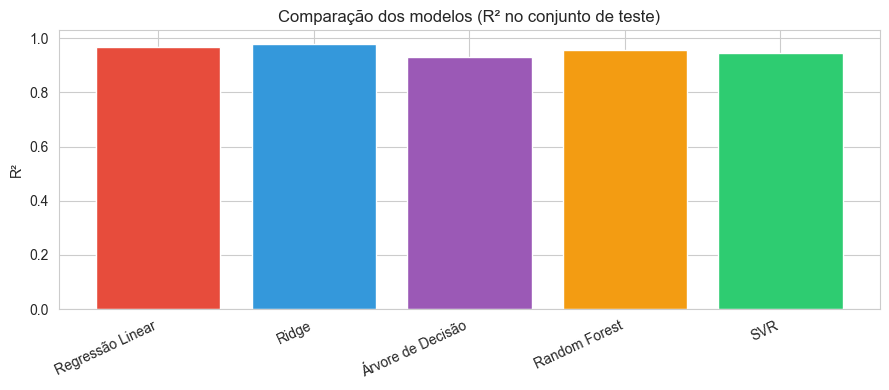

In [35]:
# Gráfico de barras: R² por modelo
plt.figure(figsize=(9, 4))
plt.bar(df_results['Modelo'], df_results['R2'], color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12'])
plt.ylabel('R²')
plt.title('Comparação dos modelos (R² no conjunto de teste)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

**Análise dos modelos:** Com base na tabela e no R², avaliamos qual modelo apresentou melhor desempenho. Modelos como Random Forest e SVR costumam capturar não linearidades; Linear e Ridge são mais interpretáveis. A escolha pode considerar o trade-off entre precisão e simplicidade.

## 4. Conclusões Finais

- **EDA:** Resumo dos achados sobre qualidade dos dados, correlações e distribuições.
- **Clusterização:** Identificação de tendências de produtividade (grupos) e de cenários discrepantes (outliers) com K-Means e DBSCAN.
- **Modelos:** Os cinco algoritmos (Regressão Linear, Ridge, Árvore de Decisão, Random Forest e SVR) foram avaliados com RMSE, MAE e R²; o melhor modelo depende do critério (ex.: maior R² ou menor RMSE) e da necessidade de interpretabilidade.
- **Pontos fortes:** Pipeline reproduzível, múltiplos algoritmos comparados, análise de outliers e tendências.
- **Limitações:** Dados limitados a uma fazenda e às variáveis disponíveis; risco de overfitting em amostras pequenas; resultados podem mudar com o dataset completo do portal.